In [109]:
import pandas as pd
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt

In [110]:
df = yf.download("CAD=X", start="1990-01-01", interval="1d", auto_adjust = True)
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,CAD=X,CAD=X,CAD=X,CAD=X,CAD=X
Date,,,,,
2003-09-17,1.36670,1.37040,1.36360,1.36670,0
2003-09-18,1.36150,1.36850,1.35970,1.36600,0
2003-09-19,1.34720,1.36300,1.34570,1.36200,0
2003-09-22,1.35420,1.35530,1.33650,1.34130,0
2003-09-23,1.35510,1.35770,1.34580,1.35490,0
...,...,...,...,...,...
2026-02-06,1.37122,1.37236,1.36258,1.37116,0
2026-02-09,1.36589,1.36664,1.35650,1.36563,0


In [ ]:
p = df['Close']
p = p[(p.index >= "2007-07-22") & (p.index < "2012-03-29")]


: 

: 

<Axes: xlabel='Date'>

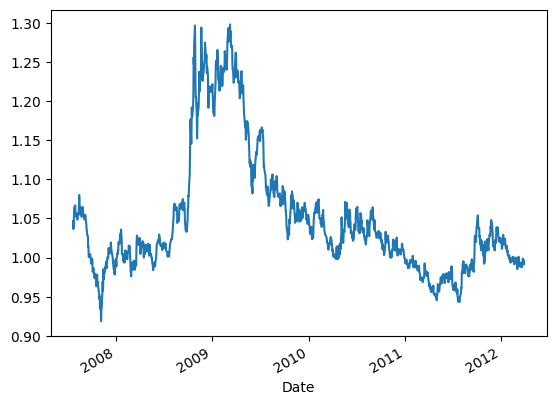

: 

: 

In [ ]:
s = p['CAD=X']
s.plot()

In [ ]:
adfuller(p)

(np.float64(-1.5638646189213663),
 np.float64(0.5017156178127697),
 18,
 1197,
 {'1%': np.float64(-3.4358248361156765),
  '5%': np.float64(-2.8639575982634757),
  '10%': np.float64(-2.5680571735171958)},
 np.float64(-7964.428150553727))

: 

: 

In [ ]:
import numpy as np
from scipy.stats import linregress

def genhurst_python(series, q=2, min_lag=1, max_lag=None):
    """
    Compute generalized Hurst exponent H(q) matching MATLAB genhurst.
    
    Parameters
    ----------
    series : array-like
        Log-price series (or any time series).
    q : float
        Moment order. Use q=2 for standard Hurst exponent.
    min_lag : int
        Minimum lag τ.
    max_lag : int or None
        Maximum lag τ. If None, uses len(series)//10.
    """
    
    x = np.asarray(series)
    x = x[~np.isnan(x)]
    
    if max_lag is None:
        max_lag = len(x) // 10
        
    # Define lags (MATLAB uses ~50 points)
    lags = np.unique(np.logspace(
        np.log10(min_lag),
        np.log10(max_lag),
        num=50
    ).astype(int))
    
    moments = []
    
    for tau in lags:
        diffs = np.abs(x[tau:] - x[:-tau]) ** q
        moments.append(np.mean(diffs))
    
    log_tau = np.log(lags)
    log_mom = np.log(moments)
    
    # Fit: log M(q,tau) = a + 2H(q) * log(tau)
    slope, intercept, *_ = linregress(log_tau, log_mom)
    
    Hq = slope / (2.0)   # divide by q? NO. MATLAB genhurst divides by 2 for q=2 case.
    
    return Hq, {"lags": lags, "log_tau": log_tau, "log_mom": log_mom}

logy = np.log(s)

H, info = genhurst_python(logy, q=2)
print("H =", H)

H = 0.46667360275230796


: 

: 

In [ ]:
from arch.unitroot import VarianceRatio

vr = VarianceRatio(logy, 10)
print(vr.summary().as_text())

     Variance-Ratio Test Results     
Test Statistic                  0.052
P-value                         0.959
Lags                               10
-------------------------------------

Computed with overlapping blocks (de-biased)


: 

: 

In [111]:
y = s.copy()
ylag = y.shift()
delta = y - ylag
delta = delta[1:]
ylag = ylag[1:]
X = np.column_stack([ylag, np.ones_like(ylag)])
X = sm.add_constant(ylag)
model = sm.OLS(delta, X).fit()
beta = model.params[1]
halflife = -np.log(2) / beta
beta, halflife


/var/folders/bc/hnzwjdn546lcc572zg36k_vc0000gn/T/ipykernel_7592/632503992.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = model.params[1]


(np.float64(-0.0055983357125461404), np.float64(123.81307877027972))

# Cointegration

In [112]:
df = yf.download(["EWC", "EWA"], start="2006-04-04", end="2012-04-09", auto_adjust = True)
df

[                       0%                       ]

[*********************100%***********************]  2 of 2 completed


Price           Close                  High                   Low             \
Ticker            EWA        EWC        EWA        EWC        EWA        EWC   
Date                                                                           
2006-04-04   8.371941  16.032997   8.404820  16.079996   8.302072  15.918859   
2006-04-05   8.515789  16.194130   8.560999  16.247842   8.429481  16.046421   
2006-04-06   8.622646  16.388840   8.634976  16.435837   8.569218  16.234418   
2006-04-07   8.544559  16.281416   8.622648  16.482835   8.495240  16.267988   
2006-04-10   8.524007  16.348551   8.556886  16.442546   8.482907  16.281411   
...               ...        ...        ...        ...        ...        ...   
2012-03-30  12.689838  21.003786  12.711428  21.107545  12.608874  20.892616   
2012-04-02  12.754606  21.344711  12.813981  21.396592  12.598075  20.951910   
2012-04-03  12.554898  21.026022  12.662850  21.337299  12.468536  20.929674   
2012-04-04  12.403762  20.655451  12.468534  20.848145  12.355183  20.507223   
2012-04-05  12.479334  20.536875  12.522515  20.707337  12.419960  20.447939   

Price            Open              Volume           
Ticker            EWA        EWC      EWA      EWC  
Date                                                
2006-04-04   8.302072  16.006142   336600   874700  
2006-04-05   8.478800  16.046421   301800   457500  
2006-04-06   8.622646  16.308273   193200   530100  
2006-04-07   8.593878  16.449266   450100  1058500  
2006-04-10   8.548666  16.415691   260100   691300  
...               ...        ...      ...      ...  
2012-03-30  12.695236  21.055665  2442700  1208700  
2012-04-02  12.630461  20.981555  1962000  1644300  
2012-04-03  12.657454  21.270597  3390000  1406800  
2012-04-04  12.430751  20.796266  3739000  1967000  
2012-04-05  12.419960  20.648046  2165600  1267400  

[1514 rows x 10 columns]

<Axes: xlabel='Date'>

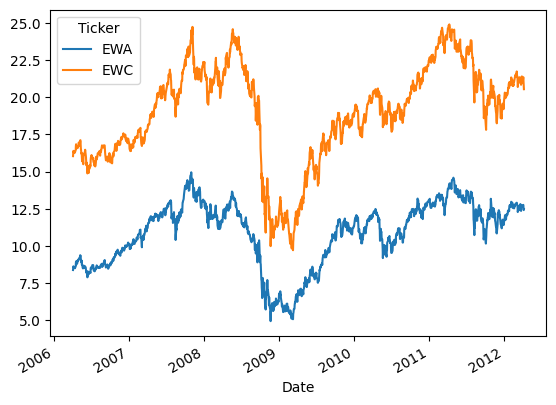

In [113]:
close = df['Close']
close.plot()

In [114]:
x = close['EWA']
y = close['EWC']
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
model.params

const    3.127154
EWA      1.459439
dtype: float64

<Axes: xlabel='Date'>

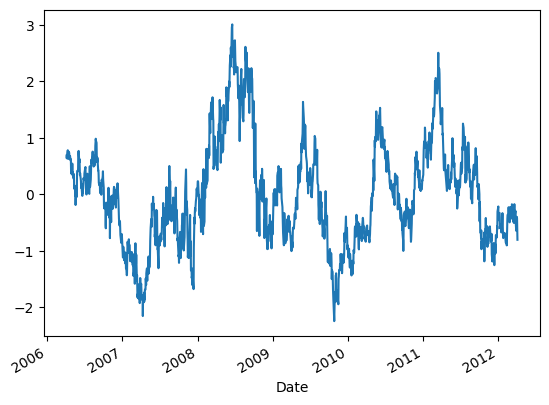

In [115]:
model.resid.plot()

In [116]:
from statsmodels.tsa.stattools import coint

x = close['EWA']

stat, pval, crit = coint(y, x, trend="c", maxlag = 1, autolag = None)

print("Engle–Granger CADF via coint")
print("stat:", stat)
print("p-value:", pval)
print("crit:", crit)

Engle–Granger CADF via coint
stat: -3.675306310610396
p-value: 0.019708335876972325
crit: [-3.90369318 -3.34017138 -3.04725436]


In [117]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

jres = coint_johansen(close, det_order = 0, k_ar_diff = 1)

print("Trace statistics:", jres.trace_stat)
print("Trace crit values (90,95,99%):\n", jres.trace_stat_crit_vals)

print("Max-eig statistics:", jres.max_eig_stat)
print("Max-eig crit values (90,95,99%):\n", jres.max_eig_stat_crit_vals)

Trace statistics: [20.54696238  4.11776287]
Trace crit values (90,95,99%):
 [[13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]
Max-eig statistics: [16.42919951  4.11776287]
Max-eig crit values (90,95,99%):
 [[12.2971 14.2639 18.52  ]
 [ 2.7055  3.8415  6.6349]]


In [54]:
df = yf.download(["EWC", "EWA", "IGE"], start="2006-04-04", end="2012-04-09", auto_adjust = True)
df = df['Close']
df

[                       0%                       ]

[*********************100%***********************]  3 of 3 completed


Ticker,EWA,EWC,IGE
Date,,,
2006-04-04,8.371941,16.032997,20.914160
2006-04-05,8.515789,16.194130,21.261831
2006-04-06,8.622646,16.388840,21.354111
2006-04-07,8.544559,16.281416,21.094429
2006-04-10,8.524007,16.348551,21.416355
...,...,...,...
2012-03-30,12.689838,21.003786,27.211388
2012-04-02,12.754606,21.344711,27.528915
2012-04-03,12.554898,21.026022,27.252813


In [ ]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

jres = coint_johansen(df, det_order = 0, k_ar_diff = 1)

print("Trace statistics:", jres.trace_stat)
print("Trace crit values (90,95,99%):\n", jres.trace_stat_crit_vals)

print("Max-eig statistics:", jres.max_eig_stat)
print("Max-eig crit values (90,95,99%):\n", jres.max_eig_stat_crit_vals)

Trace statistics: [35.21766775 17.15573578  4.58885265]
Trace crit values (90,95,99%):
 [[27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]
Max-eig statistics: [18.06193197 12.56688313  4.58885265]
Max-eig crit values (90,95,99%):
 [[18.8928 21.1314 25.865 ]
 [12.2971 14.2639 18.52  ]
 [ 2.7055  3.8415  6.6349]]


: 

In [55]:
jres.eig

NameError: name 'jres' is not defined

In [56]:
jres.evec

NameError: name 'jres' is not defined

In [57]:
shares = jres.evec[:, 0]
y3 = df.values
yport = y3 @ shares
yport = pd.Series(yport, index = df.index)


ylag = yport.shift(1)
deltaY = yport - ylag

deltaY = deltaY[1:]
ylag = ylag[1:]

x = sm.add_constant(ylag)

model = sm.OLS(deltaY, x).fit()
beta = model.params[0]

halflife = -np.log(2) / beta
halflife

NameError: name 'jres' is not defined

## Kalman Filter

In [100]:
x = df["EWA"]
y = df["EWC"]
x = np.column_stack([x, np.ones(len(x))])
delta = 0.0001
y_hat = np.full(len(x), np.nan)
e = np.full(len(x), np.nan)
Q = np.full(len(x), np.nan)

In [101]:
P = np.zeros((2, 2))
beta = np.full((2, len(x)), np.nan)
Vw = delta / (1 - delta) * np.diag(np.ones(2))
Ve = 0.001

In [102]:
y_hat

array([nan, nan, nan, ..., nan, nan, nan], shape=(1514,))

In [103]:
beta[:, 0] = 1

for i in range(1, len(x)):
    
    beta[:, i] = beta[:, i - 1]
    R = P + Vw
    
    x_t = x[i, :]
    x_t = x_t.reshape(-1, 1)
    
    beta_t = beta[:, i]
    beta_t = beta_t.reshape(-1, 1)
    
    y_hat[i] = x_t.T @ beta_t

    Q[i] = x_t.T @ R @ x_t + Ve

    e[i] = y[i] - y_hat[i]

    K = R @ x_t / Q[i]
    
    beta[:, i] = (beta_t + K * e[i]).reshape(-1)
    
    P = R - K @ x_t.T @ R

/var/folders/bc/hnzwjdn546lcc572zg36k_vc0000gn/T/ipykernel_7592/2480136670.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_hat[i] = x_t.T @ beta_t
/var/folders/bc/hnzwjdn546lcc572zg36k_vc0000gn/T/ipykernel_7592/2480136670.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Q[i] = x_t.T @ R @ x_t + Ve
/var/folders/bc/hnzwjdn546lcc572zg36k_vc0000gn/T/ipykernel_7592/2480136670.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  e[i] = y[i] - y_hat[

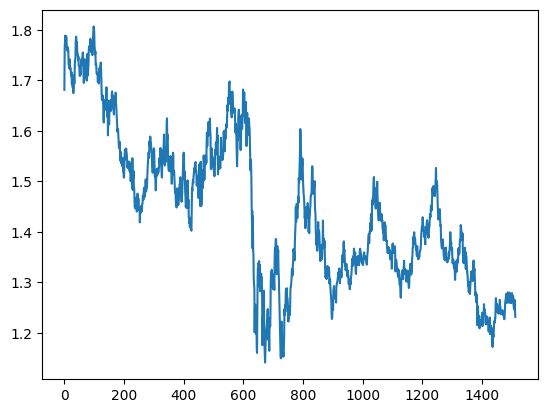

In [104]:
plt.plot(beta[0, 1:])

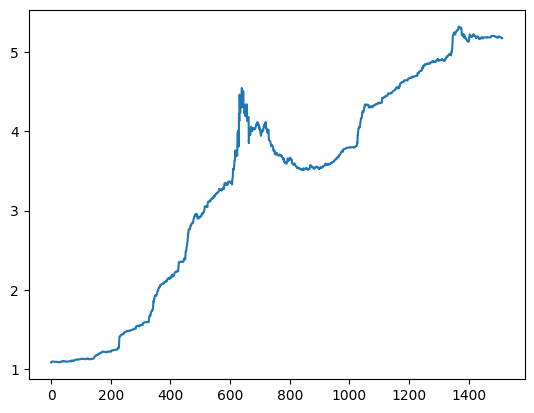

In [108]:
plt.plot(beta[1, 1:])

In [76]:
beta

array([[-0.25702889, -0.17893253, -0.14619693, ...,  1.17174361,
         1.15770361,  1.14115686],
       [17.49987365, 17.77515009, 17.78307439, ...,  6.25447203,
         6.24511456,  6.2475973 ]], shape=(2, 1514))